# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Akmal Farhan Hidayat]
- **Email:** [cdcc466d6y1390@student.devacademy.id / farhanakmal500@gmail.com]
- **ID Dicoding:** [CDCC466D6Y1390]

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Pada jam berapa rata-rata peminjaman sepeda paling tinggi dan paling rendah pada hari kerja dibandingkan hari libur selama periode 2011-2012?
- **Pertanyaan 2:** Seberapa besar perbedaan jumlah peminjaman sepeda harian antara musim panas dan musim dingin selama tahun 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [ ]:
df_day = pd.read_csv('day.csv')
df_hour = pd.read_csv('hour.csv')

print("Shape df_day:", df_day.shape)
print("Shape df_hour:", df_hour.shape)

df_day.head()

Shape df_day: (731, 16)
Shape df_hour: (17379, 17)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Dataset df_day berisi data peminjaman sepeda secara harian dengan 731 baris dan 16 kolom
- Dataset df_hour berisi data peminjaman sepeda secara per jam dengan 17.379 baris dan 17 kolom

### Assessing Data

#### Identifying ... problem

In [ ]:
df_day.isnull().sum()
df_hour.isnull().sum()

df_day.duplicated().sum()
df_hour.duplicated().sum()

df_day.dtypes
df_hour.dtypes

df_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- Kolom tanggal (dteday) perlu diubah formatnya agar Python mengenalinya sebagai data waktu, bukan sekadar teks biasa.
- Kolom-kolom seperti musim, tahun, bulan, hari libur, hari dalam seminggu, hari kerja, dan kondisi cuaca perlu diubah menjadi tipe kategori karena nilainya mewakili kelompok, bukan angka yang bisa dihitung

**Insight:** (Opsional)
- Rata-rata peminjaman sepeda per hari mencapai 4.504 unit, dengan hari tersibuk mencapai 8.714 peminjaman dan hari paling sepi hanya 22 peminjaman — menunjukkan permintaan yang sangat bervariasi tergantung kondisi
- Terdapat data kelembapan (hum) yang bernilai 0, yang secara logis tidak mungkin terjadi di dunia nyata, sehingga perlu diperiksa lebih lanjut apakah ini adalah data yang hilang atau kesalahan pencatatan

### Cleaning Data

#### Fixing ... problem

In [ ]:
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

kolom = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
for col in kolom:
    df_day[col] = df_day[col].astype('category')
    df_hour[col] = df_hour[col].astype('category')

df_day.dtypes

,0
instant,int64
dteday,datetime64[ns]
season,category
yr,category
mnth,category
holiday,category
weekday,category
workingday,category
weathersit,category
temp,float64


**Insight:** (Opsional)
- Kolom tanggal (dteday) kini tersimpan dalam format waktu yang tepat, sehingga analisis tren harian atau bulanan dapat dilakukan dengan lebih mudah
- Kolom-kolom seperti musim, bulan, hari, dan kondisi cuaca kini dikenali sebagai data kategori, bukan angka biasa — ini penting agar model tidak salah menginterpretasikan urutannya sebagai nilai numerik yang bermakna

## Exploratory Data Analysis (EDA)

### Explore ...

In [ ]:
ratajam = df_hour.groupby(['hr', 'workingday'], observed=True)['cnt'].mean().reset_index()
ratajam.columns = ['hr', 'workingday', 'avg_cnt']
print(ratajam)

ratamusim = df_day.groupby('season', observed=True)['cnt'].mean().reset_index()
ratamusim['season'] = ratamusim['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
ratamusim.columns = ['season', 'avg_cnt']
print(ratamusim)

    hr workingday     avg_cnt
0    0          0   90.800000
1    0          1   36.786290
2    1          0   69.508696
3    1          1   16.552632
4    2          0   53.171053
5    2          1    8.683778
6    3          0   25.775330
7    3          1    4.942553
8    4          0    8.264317
9    4          1    5.429787
10   5          0    8.689189
11   5          1   24.913131
12   6          0   18.742358
13   6          1  102.500000
14   7          0   43.406926
15   7          1  290.612903
16   8          0  105.653680
17   8          1  477.006048
18   9          0  171.623377
19   9          1  241.518145
20  10          0  255.909091
21  10          1  135.366935
22  11          0  315.316017
23  11          1  158.229839
24  12          0  366.259740
25  12          1  200.820926
26  13          0  372.731602
27  13          1  198.429719
28  14          0  364.645022
29  14          1  183.572289
30  15          0  358.813853
31  15          1  201.331325
32  16    

**Insight:** (Opsional)
- Di hari kerja, peminjaman sepeda sangat dipengaruhi oleh jam berangkat dan pulang kantor — puncaknya terjadi pukul 08.00 pagi (477 unit) dan 17.00 sore (525 unit)
- Musim gugur (Fall) adalah musim tersibuk dengan rata-rata 5.644 peminjaman per hari, sementara musim semi (Spring) justru paling sepi dengan hanya 2.604 peminjaman



## Visualization & Explanatory Analysis

### Pertanyaan 1:

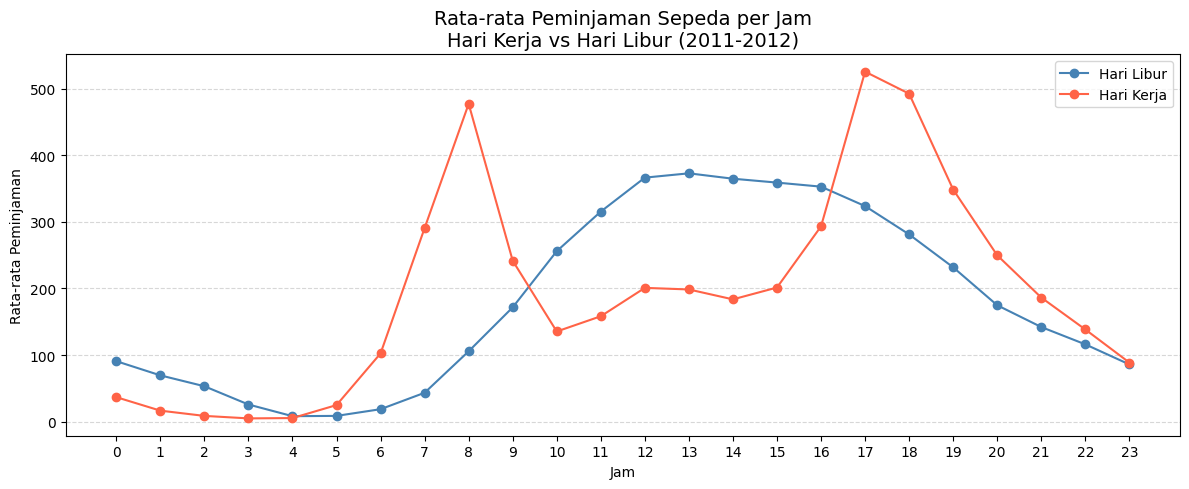

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

for workingday, label, color in [(0, 'Hari Libur', 'steelblue'), (1, 'Hari Kerja', 'tomato')]:
    data = ratajam[ratajam['workingday'] == workingday]
    ax.plot(data['hr'], data['avg_cnt'], marker='o', label=label, color=color)

ax.set_title('Rata-rata Peminjaman Sepeda per Jam\nHari Kerja vs Hari Libur (2011-2012)', fontsize=14)
ax.set_xlabel('Jam')
ax.set_ylabel('Rata-rata Peminjaman')
ax.set_xticks(range(0, 24))
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Pertanyaan 2:

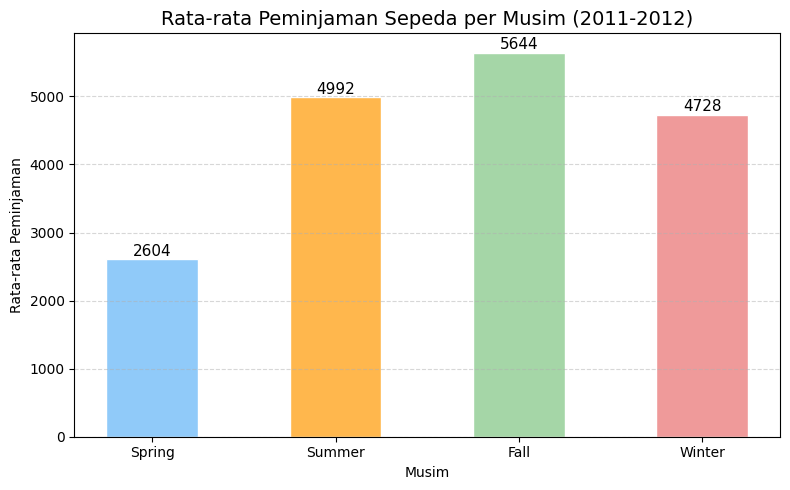

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#90CAF9', '#FFB74D', '#A5D6A7', '#EF9A9A']
bars = ax.bar(ratamusim['season'], ratamusim['avg_cnt'], color=colors, edgecolor='white', width=0.5)

ax.set_title('Rata-rata Peminjaman Sepeda per Musim (2011-2012)', fontsize=14)
ax.set_xlabel('Musim')
ax.set_ylabel('Rata-rata Peminjaman')
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{bar.get_height():.0f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Di hari kerja, peminjaman sepeda membentuk dua gelombang sibuk — pagi sekitar pukul 08.00 dan sore sekitar pukul 17.00 — yang sangat mencerminkan kebiasaan orang berangkat dan pulang kerja
- Di hari libur, tidak ada lonjakan mendadak; peminjaman naik perlahan dan mencapai puncaknya di tengah hari sekitar pukul 12.00-13.00, menandakan penggunaan lebih bersifat santai dan rekreatif
- Musim gugur (Fall) adalah musim tersibuk dengan rata-rata 5.644 peminjaman/hari, sementara musim semi (Spring) paling sepi dengan 2.604 peminjaman/hari
- Perbedaan antara musim paling ramai dan paling sepi mencapai lebih dari 2 kali lipat, membuktikan bahwa musim punya pengaruh besar terhadap minat orang bersepeda

## Analisis Lanjutan (Opsional)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Pola pemakaian sepeda sangat berbeda antara hari kerja dan hari libur. Di hari kerja, orang cenderung meminjam sepeda untuk berangkat dan pulang kerja, sehingga permintaan melonjak di pagi hari sekitar pukul 08.00 dan sore hari sekitar pukul 17.00. Sebaliknya, di hari libur orang lebih santai — permintaan naik perlahan dan puncaknya baru terjadi di tengah hari sekitar pukul 12.00-13.00
- **Conclusion pertanyaan 2:** Musim sangat mempengaruhi seberapa banyak orang bersepeda. Musim gugur (Fall) adalah periode tersibuk dengan rata-rata 5.644 peminjaman per hari, sementara musim semi (Spring) adalah yang paling sepi dengan hanya 2.604 peminjaman per hari — selisihnya lebih dari dua kali lipat

**Rekomendasi Action Item:**
- Tambah jumlah unit sepeda yang tersedia pada pukul 07.00-09.00 dan 16.00-18.00 di hari kerja untuk mengantisipasi lonjakan pengguna yang berangkat dan pulang kerja
- Buat promo atau diskon di musim semi (Spring) dan di jam-jam sepi pagi hari untuk mendorong lebih banyak orang menggunakan sepeda di periode yang biasanya sepi
- Manfaatkan dini hari (pukul 00.00-06.00) sebagai waktu terbaik untuk perawatan dan servis sepeda, karena permintaan sangat rendah sehingga tidak mengganggu pengguna

In [ ]:
df_day.to_csv('main_data.csv', index=False)